# Task 3: Customer Churn Data Preparation and EDA

Objective: prepare telecom customer data for modeling using cleaning, feature engineering, label encoding, and visual exploration.

## 1. Data Understanding

Place `WA_Fn-UseC_-Telco-Customer-Churn.csv` in `../data/raw/` before running this notebook.

In [3]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT / 'src'))

from churn_project import load_churn_data, clean_and_engineer_churn, save_churn_visuals, churn_insights

sns.set_theme(style='whitegrid')

In [5]:
df = pd.read_csv('E:\Pythoon for DataSCIENCES\Task3_Task4_Data_EDA_Project\WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

<>:1: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:1: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
C:\Users\deppa\AppData\Local\Temp\ipykernel_40172\177089008.py:1: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
  df = pd.read_csv('E:\Pythoon for DataSCIENCES\Task3_Task4_Data_EDA_Project\WA_Fn-UseC_-Telco-Customer-Churn.csv')


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [7]:
# Identify missing values and strange blank values such as ' '
missing_summary = pd.DataFrame({
    'missing_values': df.isna().sum(),
    'blank_string_values': (df.astype(str).eq(' ')).sum()
})
missing_summary[missing_summary.sum(axis=1) > 0]

,missing_values,blank_string_values
TotalCharges,0,11


## 2. Data Cleaning and Feature Engineering

The helper function converts `TotalCharges` to numeric, handles blanks, creates `TenureGroup` and `AvgMonthlySpend`, converts yes/no columns, and one-hot encodes major categorical fields.

In [8]:
cleaned = clean_and_engineer_churn(df)
cleaned.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_13-24 months,TenureGroup_25-36 months,TenureGroup_37-48 months,TenureGroup_49-60 months,TenureGroup_61-72 months
0,7590-VHVEG,1,0,1,0,1,0,No phone service,No,Yes,...,0,0,0,1,0,0,0,0,0,0
1,5575-GNVDE,0,0,0,0,34,1,No,Yes,No,...,0,0,0,0,1,0,1,0,0,0
2,3668-QPYBK,0,0,0,0,2,1,No,Yes,Yes,...,0,0,0,0,1,0,0,0,0,0
3,7795-CFOCW,0,0,0,0,45,0,No phone service,Yes,No,...,0,0,0,0,0,0,0,1,0,0
4,9237-HQITU,1,0,0,0,2,1,No,No,No,...,1,0,0,1,0,0,0,0,0,0


In [9]:
cleaned.info()
cleaned.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7032 non-null   object 
 1   gender                                 7032 non-null   int64  
 2   SeniorCitizen                          7032 non-null   int64  
 3   Partner                                7032 non-null   int64  
 4   Dependents                             7032 non-null   int64  
 5   tenure                                 7032 non-null   int64  
 6   PhoneService                           7032 non-null   int64  
 7   MultipleLines                          7032 non-null   object 
 8   OnlineSecurity                         7032 non-null   object 
 9   OnlineBackup                           7032 non-null   object 
 10  DeviceProtection                       7032 non-null   object 
 11  TechSuppo

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_13-24 months,TenureGroup_25-36 months,TenureGroup_37-48 months,TenureGroup_49-60 months,TenureGroup_61-72 months
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,...,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.00000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.495307,0.162400,0.482509,0.298493,32.421786,0.903299,0.592719,64.798208,2283.300441,0.265785,...,0.440273,0.216155,0.216297,0.336320,0.228100,0.14562,0.118316,0.108362,0.118316,0.200085
std,0.500014,0.368844,0.499729,0.457629,24.545260,0.295571,0.491363,30.085974,2266.771362,0.441782,...,0.496455,0.411650,0.411748,0.472483,0.419637,0.35275,0.323005,0.310859,0.323005,0.400092
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.587500,401.450000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.862500,3794.737500,1.000000,...,1.000000,0.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000


## 3. EDA and Visualization

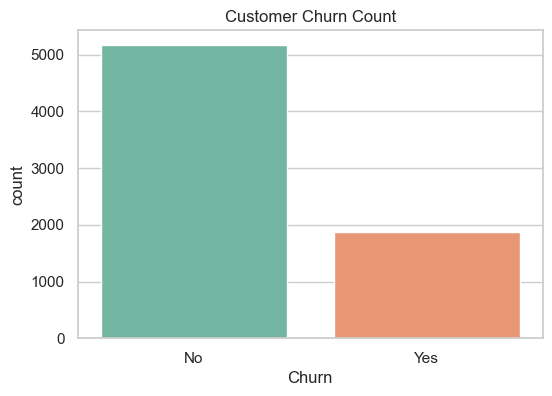

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', legend=False)
plt.title('Customer Churn Count')
plt.show()

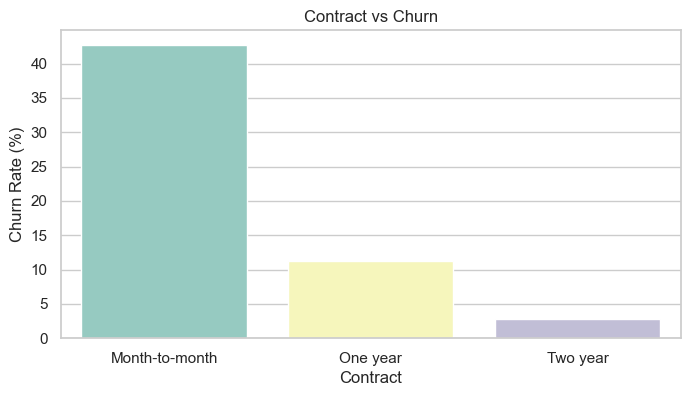

In [11]:
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean()).reset_index()
contract_churn['ChurnRate'] = contract_churn['Churn'] * 100

plt.figure(figsize=(8, 4))
sns.barplot(data=contract_churn, x='Contract', y='ChurnRate', hue='Contract', palette='Set3', legend=False)
plt.ylabel('Churn Rate (%)')
plt.title('Contract vs Churn')
plt.show()

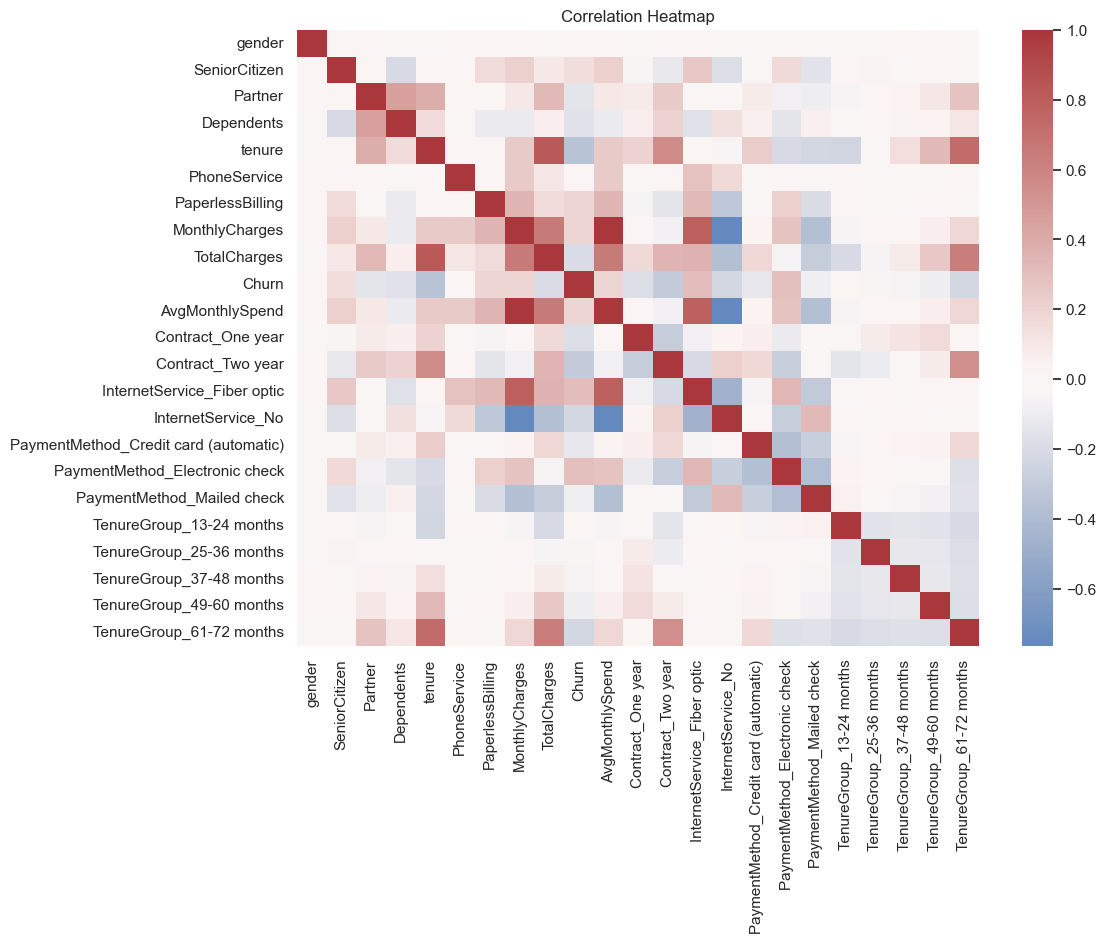

In [12]:
plt.figure(figsize=(11, 8))
sns.heatmap(cleaned.select_dtypes('number').corr(), cmap='vlag', center=0)
plt.title('Correlation Heatmap')
plt.show()

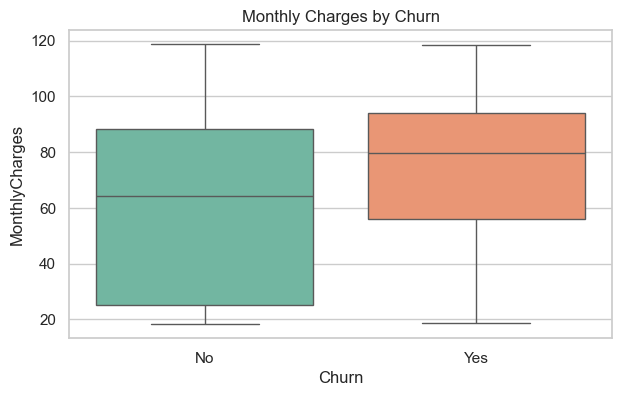

In [13]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', palette='Set2', legend=False)
plt.title('Monthly Charges by Churn')
plt.show()

## 4. Save Deliverables

In [14]:
processed_dir = PROJECT_ROOT / 'data' / 'processed'
figures_dir = PROJECT_ROOT / 'reports' / 'figures'
processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

cleaned.to_csv(processed_dir / 'customer_churn_cleaned.csv', index=False)
save_churn_visuals(df, cleaned, figures_dir)

for i, insight in enumerate(churn_insights(df, cleaned), start=1):
    print(f'{i}. {insight}')

1. Overall churn rate is 26.5%, showing the share of customers who left.
2. Highest churn appears in the Month-to-month contract group.
3. Churned customers average 74.44 monthly charges versus 61.27 for retained customers.
4. Churned customers have lower average tenure (18.0) than retained customers (37.6).
5. Average monthly spend was engineered from total charges and tenure to compare customer value more fairly.
